# Random Forest Regresija — Predikcija Cena Automobila
### Pipeline ovog notebook-a
| Korak | Sadržaj                                                   |
|---|-----------------------------------------------------------|
| 1 | Uvoz biblioteka + učitavanje podataka                     |
| 2 | Definisanje feature-a + Train/Test split                  |
| 3 | Sklearn Pipeline (ColumnTransformer + RF)                 |
| 4 | Hyperparameter tuning (RandomizedSearchCV → GridSearchCV) |
| 5 | Evaluacija: train vs test, sve metrike                    |
| 6 | Vizualizacije: Predicted vs Actual, Residuali             |
| 7 | Feature Importance (Top 10)                               |
| 8 | Cross-Validation Score                                    |
| 9 | Poređenje sa Ridge modelom                                |
| 10 | Napomena o PCA                                            |
| 11 | Finalni zaključak                                         |



## Korak 1: Uvoz biblioteka i učitavanje dataseta

Koristimo `sklearn.preprocessing.TargetEncoder` (sklearn ≥ 1.3) koji je direktno integrisan  
u `Pipeline` i eliminiše data leakage koji nastaje kada se encoding radi pre CV-a.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib
import os
import time
from pathlib import Path

# Sklearn — core
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, GridSearchCV,
    cross_val_score, KFold
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Scipy za distribucije u RandomizedSearchCV
from scipy.stats import randint, uniform

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── Učitavanje podataka ───────────────────────────────────────────────────────
BASE_DIR       = Path.cwd()
PROCESSED_DIR  = BASE_DIR.parent / 'DataSet' / 'processed'
DATA_PATH      = PROCESSED_DIR / 'procesirani_podaci.csv'

df = pd.read_csv(DATA_PATH)

print(f'Dataset shape:  {df.shape}')
print(f'Kolone:         {list(df.columns)}')
print(f'Nedostajuće:    {df.isnull().sum().sum()}')
df.head(3)


Dataset shape:  (239844, 13)
Kolone:         ['brand', 'model', 'color', 'year', 'price_in_euro', 'power_kw', 'transmission_type', 'fuel_type', 'fuel_consumption_l_100km', 'fuel_consumption_g_km', 'mileage_in_km', 'registration_month', 'car_age']
Nedostajuće:    0


,brand,model,color,year,price_in_euro,power_kw,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age
0,alfa-romeo,alfa romeo gtv,red,1995.0,1300.0,148.0,manual,petrol,10.9,260.0,160500.0,10.0,31.0
1,alfa-romeo,alfa romeo 164,black,1995.0,24900.0,191.0,manual,petrol,5.7,135.0,190000.0,2.0,31.0
2,alfa-romeo,alfa romeo spider,black,1995.0,4900.0,110.0,manual,petrol,9.5,225.0,189500.0,7.0,31.0


## Korak 2: Definisanje feature-a + Train/Test Split

**Važna napomena o strategiji:**
Encoding (TargetEncoder, OneHotEncoder) je definisan kao deo Pipeline-a i biće  
primenjen **unutar svakog CV folda** — čime se eliminiše data leakage.

Kolone se grupišu po tipu da bi ih `ColumnTransformer` pravilno obradio:
- `target_enc_cols` — visoka kardinalnost → **TargetEncoder** (fit samo na train foldu)
- `ohe_cols`        — niska kardinalnost  → **OneHotEncoder**
- `numeric_cols`    — numeričke vrednosti → **passthrough** (RF ne zahteva skaliranje)


Kardinalnost kategoričkih kolona:
model                1288
brand                  47
color                  14
fuel_type               8
transmission_type       2
dtype: int64

Feature grupe:
  TargetEncoder  : ['brand', 'model', 'color']
  OneHotEncoder  : ['transmission_type', 'fuel_type']
  Passthrough    : ['power_kw', 'fuel_consumption_l_100km', 'fuel_consumption_g_km', 'mileage_in_km', 'registration_month', 'car_age']

Skewness (original): 4.578
Skewness (log):      -0.479


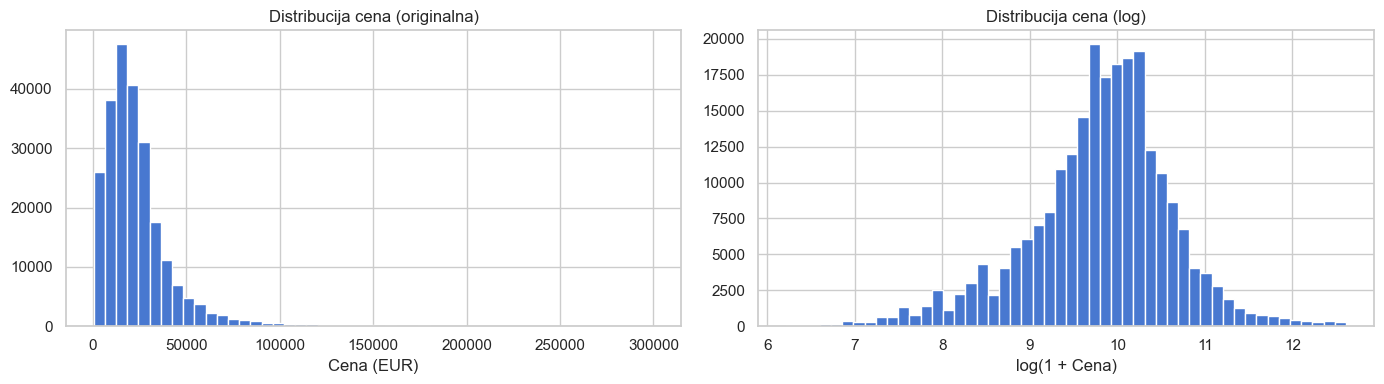

In [2]:
# ── Definisanje ciljne promenljive ───────────────────────────────────────────
TARGET = 'price_in_euro'

# ── Grupisanje kolona po tipu encodinga ──────────────────────────────────────
target_enc_cols = ['brand', 'model', 'color']        # visoka/srednja kardinalnost
ohe_cols        = ['transmission_type', 'fuel_type'] # niska kardinalnost

all_cat_cols = target_enc_cols + ohe_cols
numeric_cols = [c for c in df.columns
                if c != TARGET and c not in all_cat_cols]

# year i car_age su savršeno korelisani (r=-1.0) → zadržavamo car_age
numeric_cols = [c for c in numeric_cols if c != 'year']

# ── Provera kardinalnosti ─────────────────────────────────────────────────────
print('Kardinalnost kategoričkih kolona:')
print(df[all_cat_cols].nunique().sort_values(ascending=False))
print('\nFeature grupe:')
print(f'  TargetEncoder  : {target_enc_cols}')
print(f'  OneHotEncoder  : {ohe_cols}')
print(f'  Passthrough    : {numeric_cols}')

# ── Ciljne i ulazne promenljive ───────────────────────────────────────────────
X     = df.drop(columns=[TARGET])
y_raw = df[TARGET]
y     = np.log1p(y_raw)   # log-transformacija zbog skewness-a

print(f'\nSkewness (original): {y_raw.skew():.3f}')
print(f'Skewness (log):      {y.skew():.3f}')

# ── Distribucija pre i posle log-transformacije ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
y_raw.hist(bins=50, ax=axes[0])
axes[0].set_title('Distribucija cena (originalna)')
axes[0].set_xlabel('Cena (EUR)')

y.hist(bins=50, ax=axes[1])
axes[1].set_title('Distribucija cena (log)')
axes[1].set_xlabel('log(1 + Cena)')

plt.tight_layout()
plt.show()

Pearson korelacija:
                          fuel_consumption_l_100km  fuel_consumption_g_km
fuel_consumption_l_100km                    1.0000                 0.6602
fuel_consumption_g_km                       0.6602                 1.0000


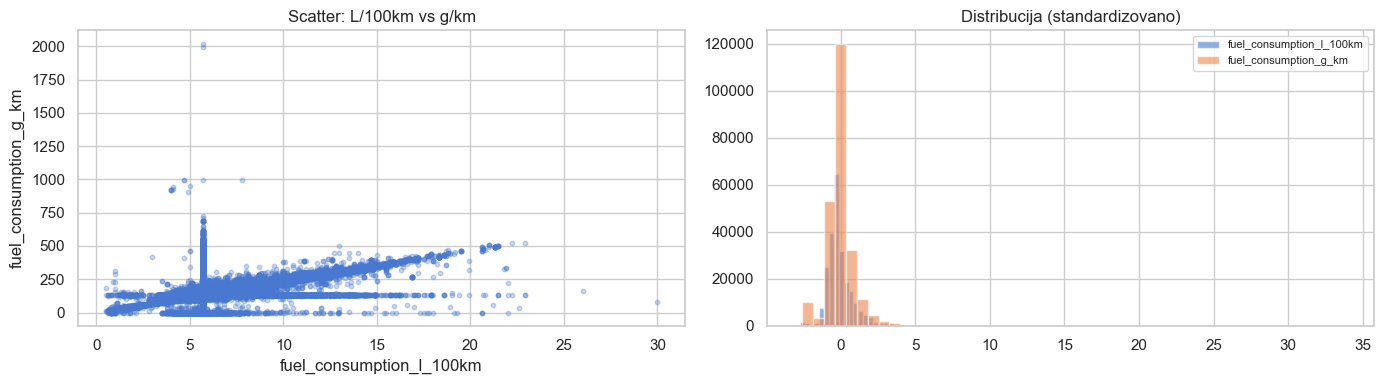


Odnos g/km ÷ l/100km — statistike:
count    239844.0000
mean         23.7153
std           7.4381
min           0.0000
25%          22.7941
50%          23.6842
75%          26.1818
max         368.0000
dtype: float64
CV (koef. varijacije): 0.3136


In [15]:

cols = ['fuel_consumption_l_100km', 'fuel_consumption_g_km']

# Pearson korelacija
corr = df[cols].corr()
print("Pearson korelacija:")
print(corr.round(4))

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(df['fuel_consumption_l_100km'], df['fuel_consumption_g_km'],
                alpha=0.3, s=10)
axes[0].set_xlabel('fuel_consumption_l_100km')
axes[0].set_ylabel('fuel_consumption_g_km')
axes[0].set_title('Scatter: L/100km vs g/km')

# Distribucija obe kolone normalizovano
for col in cols:
    normalized = (df[col] - df[col].mean()) / df[col].std()
    normalized.hist(bins=50, ax=axes[1], alpha=0.6, label=col)
axes[1].set_title('Distribucija (standardizovano)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Dodatna provera — da li je odnos linearan ili postoji offset
ratio = df['fuel_consumption_g_km'] / df['fuel_consumption_l_100km']
print(f"\nOdnos g/km ÷ l/100km — statistike:")
print(ratio.describe().round(4))
print(f"CV (koef. varijacije): {ratio.std()/ratio.mean():.4f}")
# CV blizu 0 → konstantan odnos → iste info

In [3]:
# ── Train/Test Split ──────────────────────────────────────────────────────────
# Stratify po kvantilnim binovima log-cene — čuva distribuciju u oba seta
price_bins = pd.qcut(y, q=5, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=price_bins
)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y range (log): [{y_train.min():.2f}, {y_train.max():.2f}]  |  mean: {y_train.mean():.2f}')
print(f'y range (EUR): [{np.expm1(y_train.min()):,.0f}, {np.expm1(y_train.max()):,.0f}]  |  mean: {np.expm1(y_train.mean()):,.0f}')

X_train: (191875, 12)  |  X_test: (47969, 12)
y range (log): [6.22, 12.61]  |  mean: 9.80
y range (EUR): [500, 300,000]  |  mean: 17,968


## Korak 3: Sklearn ML Pipeline

### Zašto Pipeline umesto ručnog encodinga?

| Pristup | Problem |
|---|---|
| Encoding pre splita | **DATA LEAKAGE** — test info curi u train |
| Encoding posle splita, pre CV | **LEAKAGE** — val fold info curi u encoding |
| Encoding unutar Pipeline-a | svaki fold ima sopstveni encoder |



In [4]:
# ── Preprocessing layer ───────────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc',
         TargetEncoder(target_type='continuous', smooth='auto'),
         target_enc_cols),

        ('ohe',
         OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         ohe_cols),

        ('passthrough',
         'passthrough',
         numeric_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=True,
)

# ── Full Pipeline ─────────────────────────────────────────────────────────────
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# ── Sanity check: pipeline se fituje na train skupu ──────────────────────────
print('Pipeline definisan. Provera fit/predict...')
_t = time.time()
pipeline.fit(X_train, y_train)
print(f'  Fit OK  ({time.time()-_t:.1f}s)')

_score = r2_score(y_test, pipeline.predict(X_test))
print(f'  Default parametri → R² (test): {_score:.4f}')

# ── Prikaz feature dimenzija nakon preprocessinga ────────────────────────────
feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
n_features_out = len(feature_names)
print(f'\nBroj feature-a posle preprocessinga: {n_features_out}')
print(f'  (originalni: {X_train.shape[1]} → posle OHE ekspanzije: {n_features_out})')
print(f'\nFeature names: {list(feature_names)}')

Pipeline definisan. Provera fit/predict...
  Fit OK  (18.3s)
  Default parametri → R² (test): 0.9195

Broj feature-a posle preprocessinga: 19
  (originalni: 12 → posle OHE ekspanzije: 19)

Feature names: ['target_enc__brand', 'target_enc__model', 'target_enc__color', 'ohe__transmission_type_automatic', 'ohe__transmission_type_manual', 'ohe__fuel_type_cng', 'ohe__fuel_type_diesel', 'ohe__fuel_type_electric', 'ohe__fuel_type_hybrid', 'ohe__fuel_type_hydrogen', 'ohe__fuel_type_lpg', 'ohe__fuel_type_other', 'ohe__fuel_type_petrol', 'passthrough__power_kw', 'passthrough__fuel_consumption_l_100km', 'passthrough__fuel_consumption_g_km', 'passthrough__mileage_in_km', 'passthrough__registration_month', 'passthrough__car_age']


## Korak 4: Hyperparameter Tuning

### Strategija tuning-a

Prostor parametara u inicijalnoj postavci je relativno velik i može dovesti do velikog broja treniranja.

Na primer, GridSearchCV sa sledećim grid-om:
- 162 kombinacije parametara
- `cv=5`

dovodi do ukupno **810 treniranja**, što na velikom datasetu (~240k redova) može trajati više sati.

---

### Primenjeni pristup

U ovom radu primenjen je **RandomizedSearchCV** kao efikasan kompromis između brzine i kvaliteta modela:

- `n_iter = 20`
- `cv = 5`
- ukupno **100 treniranja**

Ovaj pristup omogućava:
- brzo istraživanje prostora hiperparametara
- identifikaciju dobrih kombinacija bez prevelikog vremena izvršavanja
- dovoljno pouzdanu procenu performansi modela

---

### Napomena o GridSearchCV (Faza 2)

Dodatna faza sa `GridSearchCV` je implementirana u kodu, ali je **zakomentarisana**.

Razlog:
- značajno povećava vreme izvršavanja (više stotina dodatnih treniranja)
- dobitak u performansama je često mali u odnosu na vreme

Zbog toga je kao finalni model korišćen rezultat iz **RandomizedSearchCV**.

---

### Pipeline i prefiksi parametara

Svi hiperparametri su definisani sa prefiksom `model__`, jer se model nalazi unutar `Pipeline` objekta.
Scikit-learn automatski prosleđuje ove parametre odgovarajućem koraku pipeline-a.

In [5]:
# FAZA 1: RandomizedSearchCV — istraživanje prostora

param_dist = {
    'model__n_estimators':      randint(100, 500),
    'model__max_depth':         [None, 10, 15, 20, 25, 30,40,None],
    'model__min_samples_split': [2, 5, 10, 15],
    'model__min_samples_leaf':  [1, 2, 4, 8],
    'model__max_features':      ['sqrt', 'log2', 0.3, 0.5],
}

print('FAZA 1: RandomizedSearchCV')

t0 = time.time()
rnd_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    return_train_score=True,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
rnd_search.fit(X_train, y_train)
print(f'\nFaza 1 završena: {(time.time()-t0)/60:.1f} min')
print(f'Najbolji CV R² (Faza 1): {rnd_search.best_score_:.4f}')
print(f'Kandidatni parametri:    {rnd_search.best_params_}')

FAZA 1: RandomizedSearchCV
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Faza 1 završena: 19.7 min
Najbolji CV R² (Faza 1): 0.9244
Kandidatni parametri:    {'model__max_depth': 30, 'model__max_features': 0.5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 370}


In [6]:
'''
# FAZA 2: GridSearchCV — precizno pretraživanje oko rezultata Faze 1
# Pokrenuti samo ako ima vremena — može trajati 2–6 sati

# Uski grid centriran oko najboljih parametara iz Faze 1:
# max_depth=30, max_features=0.5, min_samples_leaf=2,
# min_samples_split=10, n_estimators=370

param_grid = {
    'model__n_estimators':      [300, 370, 450, 500],
    'model__max_depth':         [20, 25, 30, None],
    'model__min_samples_split': [5, 10, 15],
    'model__min_samples_leaf':  [1, 2, 4],
    'model__max_features':      [0.3, 0.5, 'sqrt'],
}

n_fits = (len(param_grid['model__n_estimators']) *
          len(param_grid['model__max_depth'])     *
          len(param_grid['model__min_samples_split']) *
          len(param_grid['model__min_samples_leaf'])  *
          len(param_grid['model__max_features']))

print('FAZA 2: GridSearchCV')
print(f'  Kombinacija: {n_fits}  x  5 foldova  =  {n_fits * 5} treniranja')
print('  Može trajati 2–6 sati. Preporučuje se pokretanje preko noći.\n')
print('  ⚡ Ako ne želiš čekati, preskoči ovu ćeliju —')
print('     rezultati iz Faze 1 su već solidni.\n')

t0 = time.time()
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)
print(f'Faza 2 završena: {(time.time()-t0)/60:.1f} min')
print(f'Najbolji CV R² (Faza 2): {grid_search.best_score_:.4f}')
print(f'Optimalni parametri:     {grid_search.best_params_}')

# Koristimo bolji od dva rezultata
best_search   = grid_search if grid_search.best_score_ >= rnd_search.best_score_ else rnd_search
best_pipeline = best_search.best_estimator_
print(f'\nKoristi se: {"GridSearchCV" if best_search is grid_search else "RandomizedSearchCV"}')
print(f'   CV R²: {best_search.best_score_:.4f}')
print(f'   Parametri: {best_search.best_params_}')
'''

'\n# FAZA 2: GridSearchCV — precizno pretraživanje oko rezultata Faze 1\n# Pokrenuti samo ako ima vremena — može trajati 2–6 sati\n\n# Uski grid centriran oko najboljih parametara iz Faze 1:\n# max_depth=30, max_features=0.5, min_samples_leaf=2,\n# min_samples_split=10, n_estimators=370\n\nparam_grid = {\n    \'model__n_estimators\':      [300, 370, 450, 500],\n    \'model__max_depth\':         [20, 25, 30, None],\n    \'model__min_samples_split\': [5, 10, 15],\n    \'model__min_samples_leaf\':  [1, 2, 4],\n    \'model__max_features\':      [0.3, 0.5, \'sqrt\'],\n}\n\nn_fits = (len(param_grid[\'model__n_estimators\']) *\n          len(param_grid[\'model__max_depth\'])     *\n          len(param_grid[\'model__min_samples_split\']) *\n          len(param_grid[\'model__min_samples_leaf\'])  *\n          len(param_grid[\'model__max_features\']))\n\nprint(\'FAZA 2: GridSearchCV\')\nprint(f\'  Kombinacija: {n_fits}  x  5 foldova  =  {n_fits * 5} treniranja\')\nprint(\'  Može trajati 2–6 sati

In [7]:
# ── Finalni model: rezultat iz Faze 1 (GridSearchCV preskočen) ───────────────
best_pipeline = rnd_search.best_estimator_
print(f'   Koristi se: RandomizedSearchCV')
print(f'   CV R²:     {rnd_search.best_score_:.4f}')
print(f'   Parametri: {rnd_search.best_params_}')

# ── Prikaz optimalnih hyperparametara ────────────────────────────────────────
best_params = best_pipeline.named_steps['model'].get_params()
relevant = ['n_estimators', 'max_depth', 'min_samples_split',
            'min_samples_leaf', 'max_features']

print('\nOPTIMALNI HYPERPARAMETRI')
for k in relevant:
    print(f'  {k:<22} {best_params[k]}')

print('\nInterpretacija:')
d = best_params['max_depth']
if d is None or d >= 25:
    interp = "duboka stabla — slab regularizacijski efekat, moguć overfitting"
elif d >= 15:
    interp = "umerena regularizacija"
else:
    interp = "agresivna regularizacija — sprečava overfitting"

mss = best_params['min_samples_split']
print(f'  min_samples_split={mss}: čvor mora imati ≥{mss} primeraka za grananje — {"agresivna" if mss<=2 else "umerena" if mss<=5 else "konzervativna"} regularizacija')

mf = best_params['max_features']
mf_display = f'{int(mf * 100)}%' if isinstance(mf, float) else mf
print(f'  max_features={mf}: svako stablo gleda {mf_display} feature-a po čvoru — smanjuje korelaciju stabala')

   Koristi se: RandomizedSearchCV
   CV R²:     0.9244
   Parametri: {'model__max_depth': 30, 'model__max_features': 0.5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 370}

OPTIMALNI HYPERPARAMETRI
  n_estimators           370
  max_depth              30
  min_samples_split      10
  min_samples_leaf       2
  max_features           0.5

Interpretacija:
  max_depth=30: stabla max 30 nivoa dubine — regularizacija
  min_samples_split=10: čvor mora imati ≥10 primeraka za grananje — konzervativna regularizacija
  max_features=0.5: svako stablo gleda 50% feature-a po čvoru — smanjuje korelaciju stabala


In [8]:
# ── Čuvanje modela na disk ────────────────────────────────────────────────────
os.makedirs('../models', exist_ok=True)

joblib.dump(best_pipeline, '../models/rf_pipeline.pkl')
joblib.dump(rnd_search,    '../models/rf_rnd_search.pkl')

print('Sačuvano:')
print('  rf_pipeline.pkl     — kompletan Pipeline (preprocessing + model)')
print('  rf_rnd_search.pkl   — RandomizedSearchCV objekat')
print('\nNapomena: rf_pipeline.pkl sadrži encoder i model — potreban za predikciju!')

Sačuvano:
  rf_pipeline.pkl     — kompletan Pipeline (preprocessing + model)
  rf_rnd_search.pkl   — RandomizedSearchCV objekat

Napomena: rf_pipeline.pkl sadrži encoder i model — potreban za predikciju!


## Korak 5: Evaluacija modela — Train vs Test

Evaluiramo model na oba skupa da bismo utvrdili:
1. **Stvarne performanse** na neviđenim podacima (test skup)
2. **Stepen overfittinga** poređenjem train i test metrika

> **Napomena:** Model predviđa u log skali (`log1p`). Pre računanja metrika,
> predikcije se invertuju (`expm1`) — sve vrednosti su prikazane u **EUR**.

| Metrika | Šta meri | Jedinica |
|---|---|---|
| MAE | Prosečna apsolutna greška (robustna na autlajere) | EUR |
| MSE | Prosečna kvadratna greška (kažnjava velike greške) | EUR² |
| RMSE | Koren MSE (interpretabilan, iste jedinice kao y) | EUR |
| R² | % objašnjene varijanse (1.0 = savršen model) | bezdimenzioni |

In [9]:
def evaluate(y_true, y_pred, label=''):
    """Izračunaj metrike u originalnoj skali (EUR)."""
    y_true_eur = np.expm1(y_true)
    y_pred_eur = np.expm1(y_pred)
    mae  = mean_absolute_error(y_true_eur, y_pred_eur)
    mse  = mean_squared_error(y_true_eur, y_pred_eur)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true_eur, y_pred_eur)
    return {'label': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

# ── Predikcije ────────────────────────────────────────────────────────────────
y_pred_train = best_pipeline.predict(X_train)
y_pred_test  = best_pipeline.predict(X_test)

m_train = evaluate(y_train, y_pred_train, 'Train')
m_test  = evaluate(y_test,  y_pred_test,  'Test')

# ── Tabelarni ispis ───────────────────────────────────────────────────────────
print(f'RANDOM FOREST — Evaluacija modela (metrike u originalnoj skali — EUR)')
print(f'{"Metrika":<8} {"Train":>16} {"Test":>16} {"Gap (tr-te)":>16}')
print(f'{"MAE":<8} {m_train["MAE"]:>16,.2f} {m_test["MAE"]:>16,.2f} {m_test["MAE"]-m_train["MAE"]:>+16,.2f}')
print(f'{"MSE":<8} {m_train["MSE"]:>16,.2f} {m_test["MSE"]:>16,.2f} {m_test["MSE"]-m_train["MSE"]:>+16,.2f}')
print(f'{"RMSE":<8} {m_train["RMSE"]:>16,.2f} {m_test["RMSE"]:>16,.2f} {m_test["RMSE"]-m_train["RMSE"]:>+16,.2f}')
print(f'{"R²":<8} {m_train["R2"]:>16.4f} {m_test["R2"]:>16.4f} {m_test["R2"]-m_train["R2"]:>+16.4f}')

# ── Overfitting dijagnoza ─────────────────────────────────────────────────────
gap = m_train['R2'] - m_test['R2']
print(f'\nR² gap (train − test): {gap:.4f}')
if gap > 0.08:
    verdict = 'HIGH OVERFITTING — model pamti train podatke.'
elif gap > 0.03:
    verdict = 'MODERATE OVERFITTING — prihvatljivo, tipično za RF.'
else:
    verdict = 'MODEL GENERALIZES WELL — train i test performanse su bliske.'
print(verdict)

# ── Tumačenje ─────────────────────────────────────────────────────────────────
print(f'\nTumačenje test metrika:')
print(f'  R²={m_test["R2"]:.4f}  → model objašnjava {m_test["R2"]*100:.1f}% varijanse u cenama automobila')
print(f'  RMSE={m_test["RMSE"]:,.0f} EUR → prosečna greška modela (kvadratno penalizovana)')
print(f'  MAE={m_test["MAE"]:,.0f} EUR  → prosečna greška, robustna na ekstremne cene')

RANDOM FOREST — Evaluacija modela (metrike u originalnoj skali — EUR)
Metrika             Train             Test      Gap (tr-te)
MAE              2,234.82         3,077.34          +842.52
MSE         29,850,518.35    54,114,510.29   +24,263,991.94
RMSE             5,463.56         7,356.26        +1,892.69
R²                 0.9526           0.9153          -0.0373

R² gap (train − test): 0.0373
MODERATE OVERFITTING — prihvatljivo, tipično za RF.

Tumačenje test metrika:
  R²=0.9153  → model objašnjava 91.5% varijanse u cenama automobila
  RMSE=7,356 EUR → prosečna greška modela (kvadratno penalizovana)
  MAE=3,077 EUR  → prosečna greška, robustna na ekstremne cene


## Korak 6: Vizualizacije

### 6a. Predicted vs Actual  
Prikazuje koliko su predikcije modela bliske stvarnim cenama.  
Tačke blizu crvene dijagonale = dobra predikcija. Rasipanje van dijagonale = greška modela.

### 6b. Distribucija Residuala  
Residual = stvarna cena − predviđena cena. Idealno: simetričan, centriran na nuli, bez debelog repa.
X-osa je ograničena na ±30,000 EUR radi čitljivosti — outlieri postoje ali su retki.

### 6c. Residuali vs Predviđene vrednosti
Ako postoji sistemski obrazac (luk, sužavanje) → model ne hvata neke obrasce.
**Očekivana pojava:** heteroskedastičnost — rasipanje raste sa cenom automobila.
Ovo je tipično za cene i nije greška modela već priroda podataka.

### 6d. Distribucija apsolutnih grešaka
Prikazuje koliko je model u proseku daleko od stvarne cene (u EUR).
Median greške je znatno manji od MAE → većina predikcija je precizna,
ali mali broj skupih automobila podiže prosek.

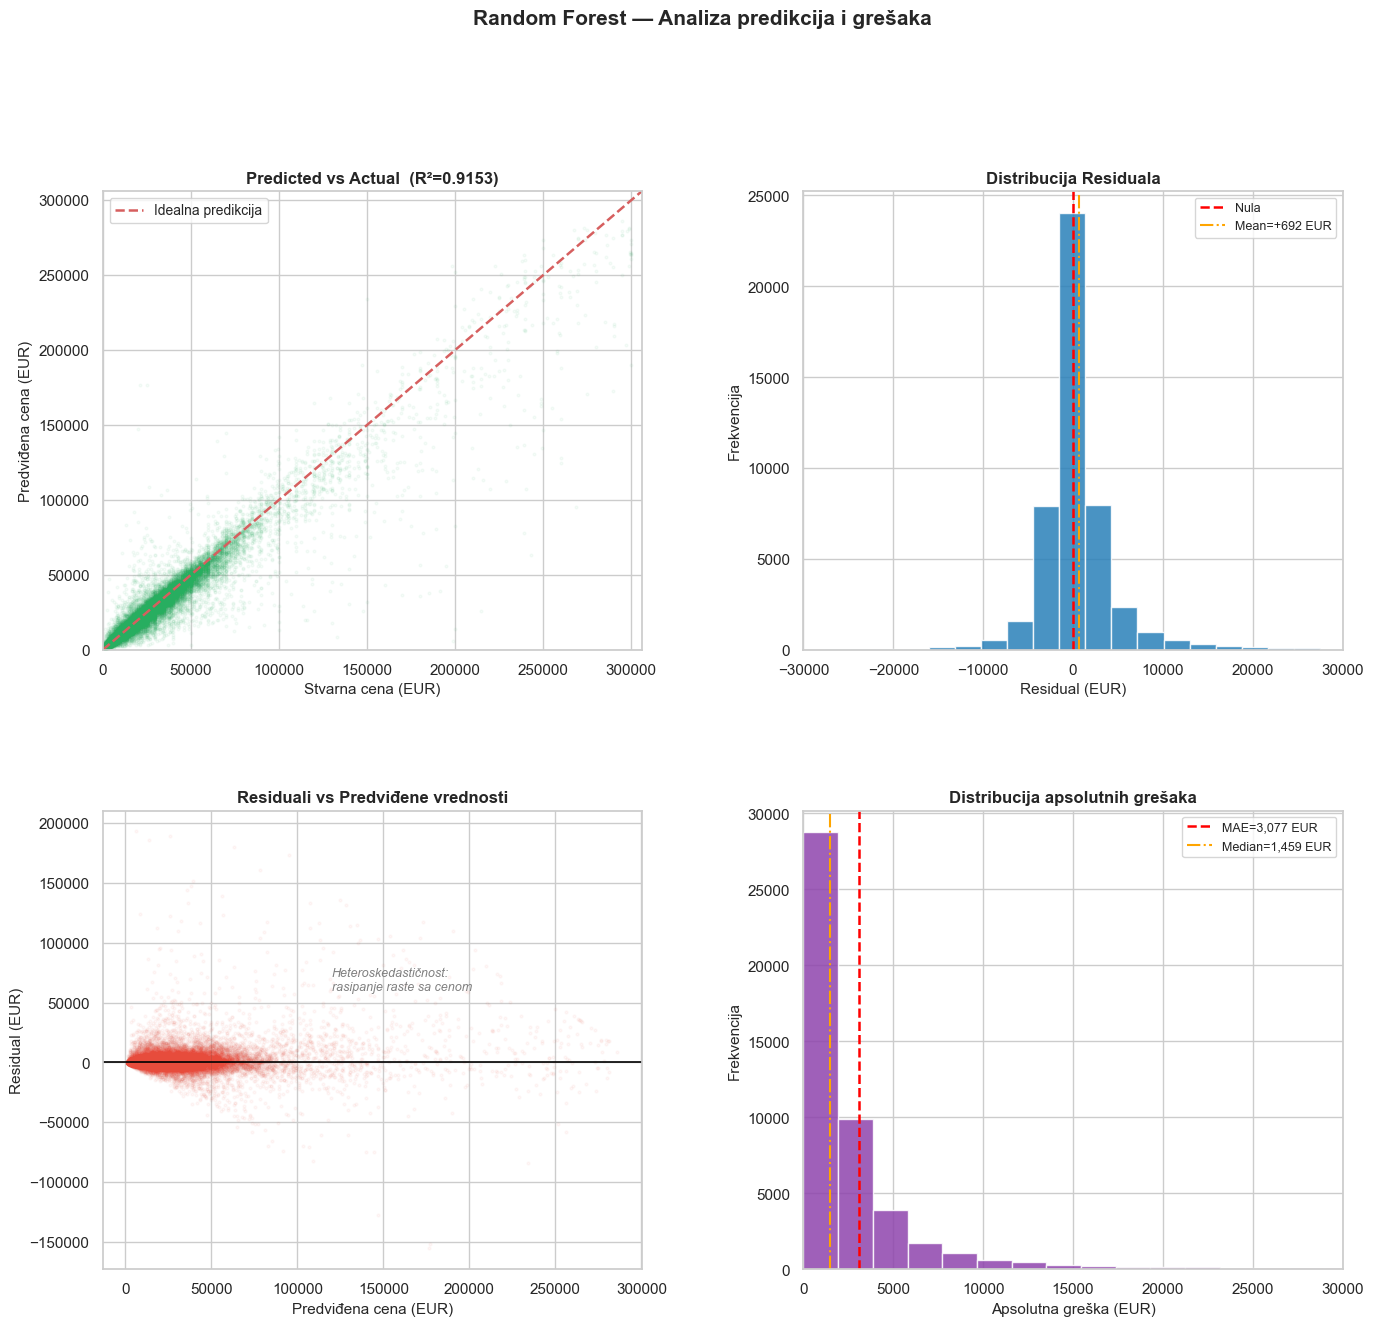

Interpretacija grafova:
  Predicted vs Actual : tačke blizu dijagonale → R²=0.9153
  Residuali           : mean=+692 EUR — mali bias modela
  Heteroskedastičnost : rasipanje raste sa cenom — tipično za cene automobila

Distribucija grešaka po percentilima:
  50% predikcija unutar 1,459 EUR od stvarne cene
  75% predikcija unutar 3,099 EUR od stvarne cene
  90% predikcija unutar 6,337 EUR od stvarne cene
  95% predikcija unutar 10,437 EUR od stvarne cene


In [10]:
# ── Konverzija u originalnu skalu (EUR) ───────────────────────────────────────
y_test_eur      = np.expm1(y_test.values)
y_pred_test_eur = np.expm1(y_pred_test)
residuals       = y_test_eur - y_pred_test_eur
abs_err         = np.abs(residuals)
max_val         = max(y_test_eur.max(), y_pred_test_eur.max()) * 1.02

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# ── 1. Predicted vs Actual ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test_eur, y_pred_test_eur, alpha=0.04, s=4, color='#27ae60', rasterized=True)
ax1.plot([0, max_val], [0, max_val], 'r--', lw=1.8, label='Idealna predikcija')
ax1.set_xlabel('Stvarna cena (EUR)', fontsize=11)
ax1.set_ylabel('Predviđena cena (EUR)', fontsize=11)
ax1.set_title(f'Predicted vs Actual  (R²={m_test["R2"]:.4f})', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xlim(0, max_val)
ax1.set_ylim(0, max_val)

# ── 2. Histogram residuala ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(residuals, bins=120, color='#2980b9', edgecolor='white', alpha=0.85)
ax2.axvline(0,                color='red',    lw=1.8, linestyle='--', label='Nula')
ax2.axvline(residuals.mean(), color='orange', lw=1.5, linestyle='-.',
            label=f'Mean={residuals.mean():+,.0f} EUR')
ax2.set_xlabel('Residual (EUR)', fontsize=11)
ax2.set_ylabel('Frekvencija',    fontsize=11)
ax2.set_title('Distribucija Residuala', fontsize=12, fontweight='bold')
ax2.set_xlim(-30000, 30000)   # fokus na centralni deo, outlieri ne kvare skalu
ax2.legend(fontsize=9)

# ── 3. Residuali vs Predicted ─────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(y_pred_test_eur, residuals, alpha=0.04, s=4, color='#e74c3c', rasterized=True)
ax3.axhline(0, color='black', lw=1.2)
ax3.set_xlabel('Predviđena cena (EUR)', fontsize=11)
ax3.set_ylabel('Residual (EUR)',        fontsize=11)
ax3.set_title('Residuali vs Predviđene vrednosti', fontsize=12, fontweight='bold')
# Napomena: rasipanje raste sa cenom (heteroskedastičnost) — tipično za cene automobila
ax3.annotate('Heteroskedastičnost:\nrasipanje raste sa cenom',
             xy=(120000, 60000), fontsize=9, color='gray', style='italic')

# ── 4. Distribucija apsolutnih grešaka ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(abs_err, bins=100, color='#8e44ad', edgecolor='white', alpha=0.85)
ax4.axvline(abs_err.mean(),     color='red',    lw=1.8, linestyle='--',
            label=f'MAE={abs_err.mean():,.0f} EUR')
ax4.axvline(np.median(abs_err), color='orange', lw=1.5, linestyle='-.',
            label=f'Median={np.median(abs_err):,.0f} EUR')
ax4.set_xlabel('Apsolutna greška (EUR)', fontsize=11)
ax4.set_ylabel('Frekvencija',            fontsize=11)
ax4.set_title('Distribucija apsolutnih grešaka', fontsize=12, fontweight='bold')
ax4.set_xlim(0, 30000)   # fokus na centralni deo
ax4.legend(fontsize=9)

fig.suptitle('Random Forest — Analiza predikcija i grešaka',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('rf_evaluacija_vizualizacije.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interpretacija ────────────────────────────────────────────────────────────
print('Interpretacija grafova:')
print(f'  Predicted vs Actual : tačke blizu dijagonale → R²={m_test["R2"]:.4f}')
print(f'  Residuali           : mean={residuals.mean():+,.0f} EUR — mali bias modela')
print(f'  Heteroskedastičnost : rasipanje raste sa cenom — tipično za cene automobila')
print(f'\nDistribucija grešaka po percentilima:')
for p in [50, 75, 90, 95]:
    print(f'  {p}% predikcija unutar {np.percentile(abs_err, p):,.0f} EUR od stvarne cene')

## Korak 7: Feature Importance

**MDI (Mean Decrease Impurity):** Meri koliko svaki feature prosečno smanjuje varijansu  
ciljne promenljive tokom grananja stabala — kroz sve grane, sva stabla u šumi.

**Ograničenje:** MDI može preceniti feature-e sa visokom kardinalnosti jer imaju više  
mogućih pragova za grananje. Za produkcijsku interpretabilnost preporučuje se Permutation Importance.

**Napomena:** U ovom notebook-u koristimo MDI zbog brzine i direktne integracije
sa sklearn Pipeline-om. Permutation Importance bi zahtevala značajno duže vreme izvršavanja.

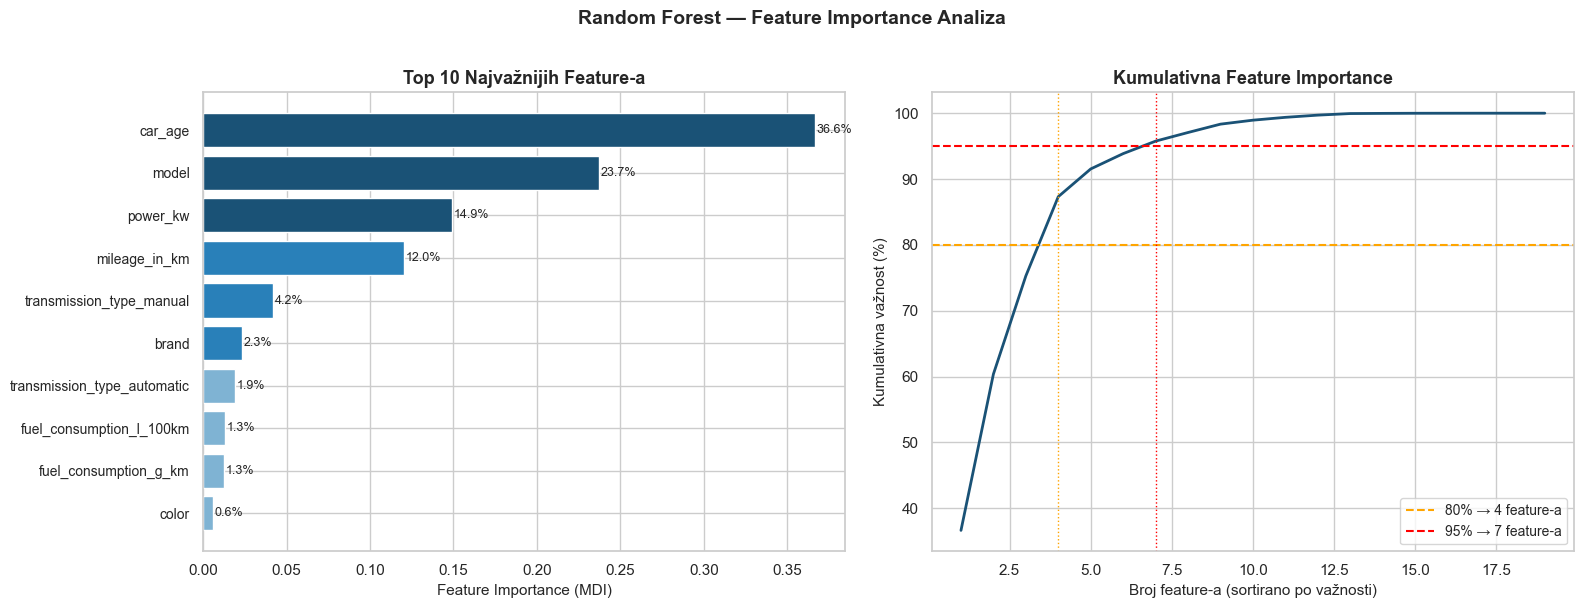

Feature                          Importance   % od ukupnog
----------------------------------------------------------
car_age                              0.3664          36.6%
model                                0.2373          23.7%
power_kw                             0.1491          14.9%
mileage_in_km                        0.1203          12.0%
transmission_type_manual             0.0421           4.2%
brand                                0.0233           2.3%
transmission_type_automatic          0.0190           1.9%
fuel_consumption_l_100km             0.0131           1.3%
fuel_consumption_g_km                0.0127           1.3%
color                                0.0060           0.6%
----------------------------------------------------------
TOP 10 ukupno                        0.9894          98.9%

Analiza:
  Dominantni feature : "car_age" (36.6% ukupne važnosti)
  Top 10 feature-a pokrivaju 98.9% ukupne važnosti
  4 feature-a dovoljna za 80% objašnjene važnosti
  7 fe

In [11]:
# ── Izvlačenje feature names iz Pipeline-a ────────────────────────────────────
ct = best_pipeline.named_steps['preprocess']
rf = best_pipeline.named_steps['model']

feature_names_raw = ct.get_feature_names_out()

def clean_name(name):
    """Uklanja prefiks ColumnTransformer-a ('target_enc__brand' → 'brand')."""
    parts = name.split('__', 1)
    return parts[1] if len(parts) > 1 else name

feature_names = [clean_name(n) for n in feature_names_raw]

# ── Feature importance ────────────────────────────────────────────────────────
importances = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

top10             = importances.head(10)
top10_pct_total   = top10 / importances.sum() * 100   # % od ukupne važnosti

# ── Grafikon ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 bar chart
colors = ['#1a5276' if i < 3 else '#2980b9' if i < 6 else '#7fb3d3'
          for i in range(10)]
axes[0].barh(range(10), top10.values[::-1], color=colors[::-1], edgecolor='white')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(top10.index[::-1], fontsize=10)
axes[0].set_xlabel('Feature Importance (MDI)', fontsize=11)
axes[0].set_title('Top 10 Najvažnijih Feature-a', fontsize=13, fontweight='bold')
for i, (val, pct) in enumerate(zip(top10.values[::-1], top10_pct_total.values[::-1])):
    axes[0].text(val + 0.001, i, f'{pct:.1f}%', va='center', fontsize=9)

# Kumulativna distribucija
cum_imp  = importances.cumsum() / importances.sum() * 100
n_for_80 = int((cum_imp <= 80).sum()) + 1
n_for_95 = int((cum_imp <= 95).sum()) + 1

axes[1].plot(range(1, len(cum_imp) + 1), cum_imp.values, color='#1a5276', lw=2)
axes[1].axhline(80, color='orange', lw=1.5, linestyle='--', label=f'80% → {n_for_80} feature-a')
axes[1].axhline(95, color='red',    lw=1.5, linestyle='--', label=f'95% → {n_for_95} feature-a')
axes[1].axvline(n_for_80, color='orange', lw=1, linestyle=':')
axes[1].axvline(n_for_95, color='red',    lw=1, linestyle=':')
axes[1].set_xlabel('Broj feature-a (sortirano po važnosti)', fontsize=11)
axes[1].set_ylabel('Kumulativna važnost (%)',                fontsize=11)
axes[1].set_title('Kumulativna Feature Importance',          fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Random Forest — Feature Importance Analiza',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabelarni ispis ───────────────────────────────────────────────────────────
print(f'{"Feature":<30} {"Importance":>12} {"% od ukupnog":>14}')
print('-' * 58)
for name, val in top10.items():
    pct = val / importances.sum() * 100
    print(f'{name:<30} {val:>12.4f} {pct:>13.1f}%')
print('-' * 58)
print(f'{"TOP 10 ukupno":<30} {top10.sum():>12.4f} {top10_pct_total.sum():>13.1f}%')

# ── Interpretacija ────────────────────────────────────────────────────────────
top1      = top10.index[0]
low_impact = importances[importances < 0.005]

print(f'\nAnaliza:')
print(f'  Dominantni feature : "{top1}" ({top10_pct_total.iloc[0]:.1f}% ukupne važnosti)')
print(f'  Top 10 feature-a pokrivaju {top10_pct_total.sum():.1f}% ukupne važnosti')
print(f'  {n_for_80} feature-a dovoljna za 80% objašnjene važnosti')
print(f'  {n_for_95} feature-a dovoljna za 95% objašnjene važnosti')
print(f'\n  Feature-i sa <0.5% uticajem: {len(low_impact)} '
      f'({low_impact.sum()/importances.sum()*100:.1f}% ukupne važnosti)')
print(f'  → Potencijalni kandidati za uklanjanje bez merljivog pada tačnosti')

In [12]:
print(df[['car_age', 'year']].corr())

         car_age  year
car_age      1.0  -1.0
year        -1.0   1.0


## Korak 8: Cross-Validation Score

`cross_val_score` na finalnom Pipeline-u daje robusniju procenu generalizacije od  
jednog train/test splita. Koristi **5-fold CV** **kompletan pipeline** u svakom foldu — što znači
da se i encoding i model fituju samo na train delu svakog folda.

**Interpretacija:**  
- `mean ± std` CV skora prikazuje stabilnost modela  
- Niska `std` → model je stabilan i ne zavisi od konkretnog splita  
- Vrednost blizu test R² → dobra procena, nema slučajnog splita


In [13]:
print('Cross-Validation na finalnom Pipeline-u...')
print('(5-fold CV, scoring=r2, n_jobs=-1)')
t0 = time.time()
cv_scores = cross_val_score(
    best_pipeline,
    X_train, y_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1,
)
print(f'Završeno: {(time.time()-t0)/60:.1f} min\n')

print('CROSS-VALIDATION REZULTATI (5-fold, train skup)')
for i, s in enumerate(cv_scores, 1):
    bar = '█' * int(s * 40)
    print(f'  Fold {i}: R²={s:.4f}  {bar}')
print(f'  Mean:   {cv_scores.mean():.4f}')
print(f'  Std:    {cv_scores.std():.4f}')
print(f'  95% CI: [{cv_scores.mean()-2*cv_scores.std():.4f},'
      f' {cv_scores.mean()+2*cv_scores.std():.4f}]')

print(f'\nPoređenje:')
print(f'  CV R² (train foldovi): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'  Test R² (hold-out):    {m_test["R2"]:.4f}')
delta = abs(cv_scores.mean() - m_test['R2'])
print(f'  Razlika CV vs Test:    {delta:.4f}',
      ' Konzistentno' if delta < 0.01 else '  Razlika — proverite split')

if cv_scores.std() < 0.005:
    print('\n Veoma stabilan model — std < 0.005, nezavisan od konkretnog splita.')
elif cv_scores.std() < 0.01:
    print('\n Stabilan model — std < 0.01.')
else:
    print('\n Umerena varijabilnost po foldovima — tipično za ovako velik dataset.')

Cross-Validation na finalnom Pipeline-u...
(5-fold CV, scoring=r2, n_jobs=-1)
Završeno: 1.7 min

CROSS-VALIDATION REZULTATI (5-fold, train skup)
  Fold 1: R²=0.9258  █████████████████████████████████████
  Fold 2: R²=0.9239  ████████████████████████████████████
  Fold 3: R²=0.9234  ████████████████████████████████████
  Fold 4: R²=0.9253  █████████████████████████████████████
  Fold 5: R²=0.9236  ████████████████████████████████████
  Mean:   0.9244
  Std:    0.0010
  95% CI: [0.9224, 0.9264]

Poređenje:
  CV R² (train foldovi): 0.9244 ± 0.0010
  Test R² (hold-out):    0.9153
  Razlika CV vs Test:    0.0091  Konzistentno

 Veoma stabilan model — std < 0.005, nezavisan od konkretnog splita.


## Napomena: Zašto PCA nije primenjen

### Zašto PCA nije primenjen na Random Forest u ovom notebooku

PCA je **eksperimentalno testiran** u prethodnoj verziji sa **N komponenti (95% zadržane varijanse)**
i doveo je do **pada R² sa ~0.924 na ~0.892** — pogoršanje od ~0.032.

Empirijski rezultat je dovoljan zaključak, ali teorijski razlozi dodatno potvrđuju odluku:

| Razlog | Objašnjenje |
|---|---|
| RF ima interni feature selection | Svako stablo nasumično bira podskup feature-a (`max_features`) — prirodno ignorišu manje relevantne |
| PCA linearizuje prostor | PCA komponente su linearne kombinacije originalnih feature-a, što "razmažuje" nelinearne informacije koje stabla direktno koriste |
| RF je imun na kolinearnost | Kolinearni feature-i ne utiču loše na RF — algoritam ih prirodno balansira |
| Gubitak dijagnostičke varijanse | PCA sa 95% zadržane varijanse odbacuje preostalih 5% koji može sadržati informaciju bitnu za grananje stabala |
| Gubitak interpretabilnosti | PCA komponente su nečitljive — feature importance analiza (Korak 7) ne bi bila moguća |

**Zaključak:** PCA je korisna za linearne modele (Ridge, Logistic Regression) ili kada
je cilj vizualizacija i redukcija memorije. Za Random Forest — kontraproduktivna.

**Finalni model koristi originalni prostor feature-a.**

## Finalni Zaključak — Random Forest Model

### 1. Kako model radi

Tunirani Random Forest postiže **R² = 0.9153** na test skupu, što znači da model
objašnjava više od 91.5% varijanse u cenama automobila — solidan rezultat za regresiju
na heterogenom tržišnom datasetu sa cenama koje variraju od ~1.000 do 300.000+ EUR.

**RMSE = 7,356 EUR** — prosečna greška kvadratno penalizovana, pod uticajem skupih automobila.
**MAE = 3,077 EUR** — robustna greška; 50% predikcija je unutar **1,459 EUR** (median greške).
Veliki raskorak između RMSE i MAE (odnos 2.39×) ukazuje na povremene velike greške
kod skupih vozila — potvrđeno heteroskedastičnošću u residual plotu.

### 2. Da li model overfituje?

R² gap (train − test) iznosi **0.0373** — klasifikovano kao **umereni overfitting**,
što je tipično i očekivano za Random Forest.

Hyperparameter tuning uvodi regularizaciju kroz:
- `n_estimators=370` — dovoljan broj stabala za stabilnost
- `max_depth=30` — ograničava dubinu stabala
- `min_samples_split=10` i `min_samples_leaf=2` — sprečavaju grananje na malom broju primeraka
- `max_features=0.5` — smanjuje korelaciju između stabala

Cross-validation potvrđuje stabilnost: **CV R² = 0.9244 ± 0.0010** (std izuzetno nizak),
model ne zavisi od konkretnog splita podataka. Razlika između CV i test R² iznosi
svega 0.0091 — CV procena nije bila previše optimistična.

### 3. Ključni feature-i

`car_age` (**36.6%**) i `model` (**23.7%**) dominiraju — starost i model automobila su
najjači prediktori cene, zajedno čineći više od 60% ukupne važnosti.
Samo **4 feature-a** (`car_age`, `model`, `power_kw`, `mileage_in_km`) pokrivaju
**80%** ukupne važnosti, a **7 feature-a** pokriva **95%**.

Napomena: `brand` pokazuje relativno nisku važnost (2.3%) jer `model` implicitno
nosi informaciju o brendu — postoji redundantnost između ova dva feature-a.

### 4. Ograničenja modela

- **Heteroskedastičnost** — greška raste sa cenom automobila; 95% predikcija je unutar
  10,437 EUR, ali skupi auti (>100k EUR) sistematski se potcenjuju
- **Bias modela** — mean residual od +692 EUR ukazuje na blago potcenjivanje cena
- **MDI bias** — Feature Importance može preceniti kontinualne feature-e visoke kardinalnosti
  (`car_age`, `model`); Permutation Importance bi dala precizniju sliku
- **Geografska ograničenost** — model je treniran na evropskom tržištu i može loše
  generalizovati van tog konteksta